[Warn] pkl 파일이 없어 더미 데이터로 진행한다

[Train] Offline tri-zone pretrain start
[Epoch    1/300] loss=2.5105 | pos_den=0.062 neg_den=0.688 | avg_pos=32.0 avg_neg=352.3


[Epoch   50/300] loss=0.0044 | pos_den=0.062 neg_den=0.688 | avg_pos=32.0 avg_neg=352.3
[Epoch  100/300] loss=0.0017 | pos_den=0.062 neg_den=0.688 | avg_pos=32.0 avg_neg=352.4
[Epoch  150/300] loss=0.0010 | pos_den=0.062 neg_den=0.689 | avg_pos=32.0 avg_neg=352.7
[Epoch  200/300] loss=0.0007 | pos_den=0.062 neg_den=0.688 | avg_pos=32.0 avg_neg=352.4
[Epoch  250/300] loss=0.0005 | pos_den=0.062 neg_den=0.688 | avg_pos=32.0 avg_neg=352.2
[Epoch  300/300] loss=0.0004 | pos_den=0.062 neg_den=0.689 | avg_pos=32.0 avg_neg=352.5

[Vis] t-SNE 3D + Utility PCA->RGB coloring


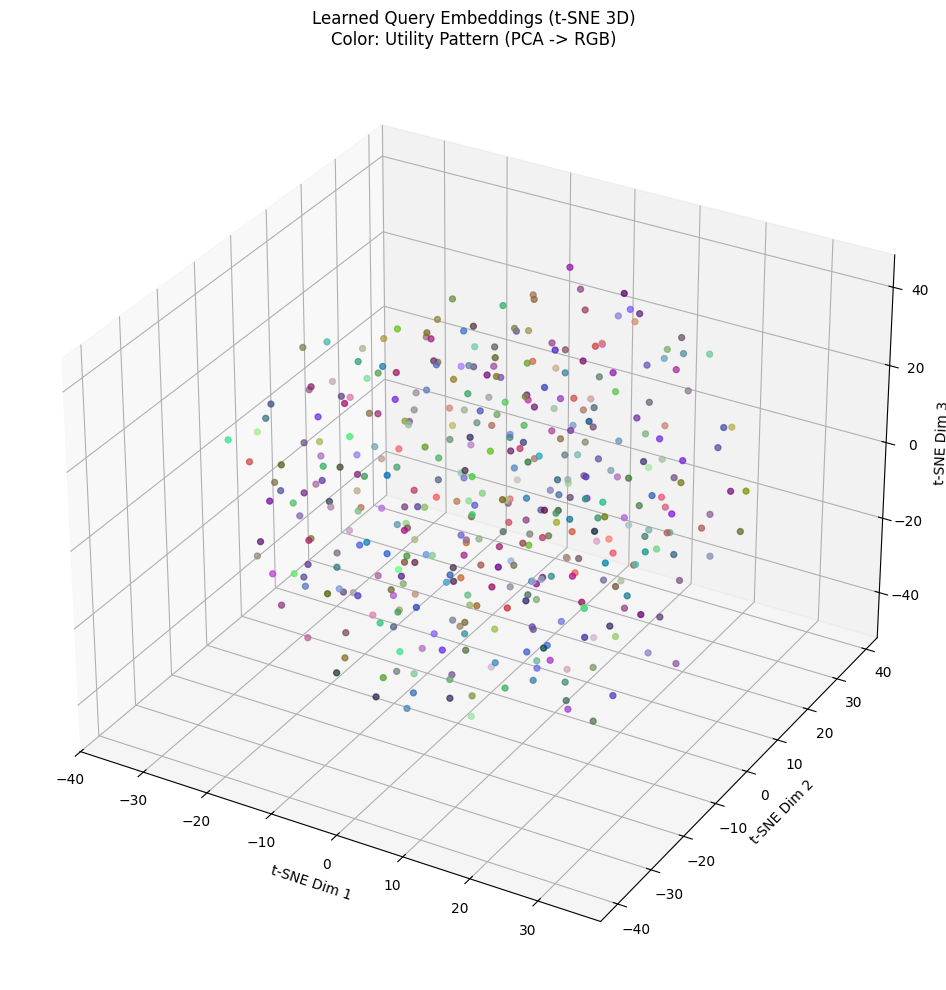

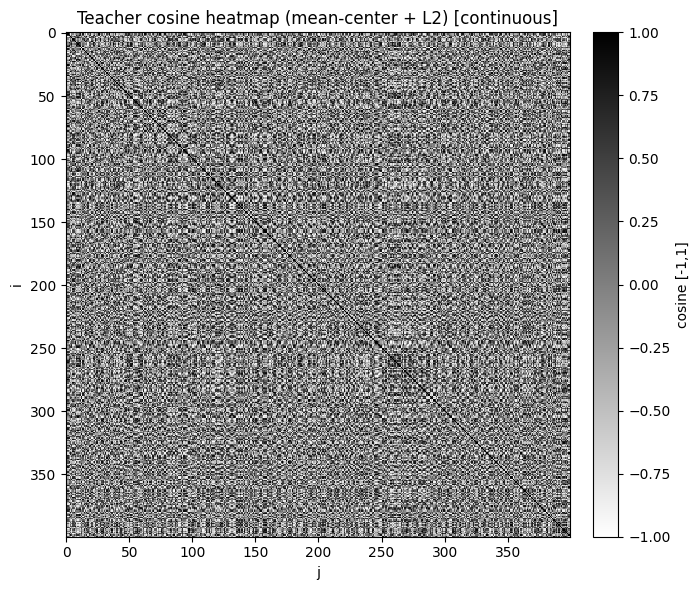

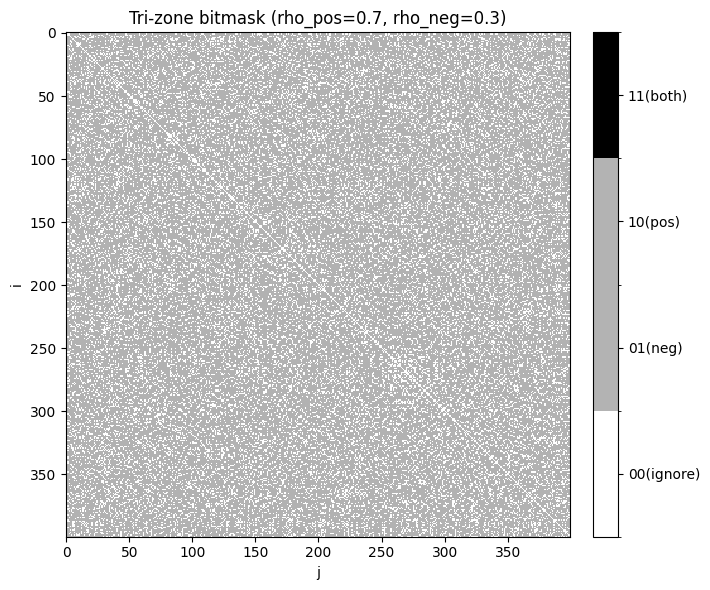

[Tri-zone stats] avg_pos_per_row=36.7, avg_neg_per_row=274.8

[Done]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_teacher_distribution(utility_matrix):
    """
    utility_matrix: (N_samples, 11) 형태의 numpy array (Score or Utility)
    """
    N, M = utility_matrix.shape
    print(f"Dataset Shape: {N} queries x {M} models")
    
    # ---------------------------------------------------------
    # 1. Teacher Signature: Mean-Center + L2 Normalization
    # ---------------------------------------------------------
    # (1) Mean Centering: 각 쿼리 내에서 모델들의 평균을 뺌
    #     -> 어떤 모델이 상대적으로 더 좋은지/나쁜지 패턴만 남김
    u_mean = np.mean(utility_matrix, axis=1, keepdims=True)
    u_centered = utility_matrix - u_mean
    
    # (2) L2 Normalization: 벡터 길이를 1로 맞춤
    norm = np.linalg.norm(u_centered, axis=1, keepdims=True) + 1e-8
    u_tilde = u_centered / norm
    
    # ---------------------------------------------------------
    # 2. Compute Cosine Similarity (Sample-Sample)
    # ---------------------------------------------------------
    # N이 10,000개면 10,000 x 10,000 매트릭스 (약 400MB 메모리)
    # 메모리가 부족하면 N을 5,000 정도로 줄여서 샘플링하세요.
    if N > 10000:
        print("⚠️ 샘플이 너무 많아 10,000개만 랜덤 샘플링하여 분석합니다.")
        indices = np.random.choice(N, 10000, replace=False)
        u_tilde = u_tilde[indices]
    
    print("Computing Cosine Similarity Matrix...")
    similarity_matrix = np.dot(u_tilde, u_tilde.T)
    
    # ---------------------------------------------------------
    # 3. Extract Off-diagonal Entries
    # ---------------------------------------------------------
    # 자기 자신(1.0)과 중복 쌍을 제외하고 상삼각행렬만 추출
    upper_tri_indices = np.triu_indices(u_tilde.shape[0], k=1)
    sim_values = similarity_matrix[upper_tri_indices]
    
    # ---------------------------------------------------------
    # 4. Calculate Percentiles for Thresholds
    # ---------------------------------------------------------
    # 전략: 
    # - Pos: 상위 10~20% 지점
    # - Neg: 하위 50% 지점 (Median)
    
    p_80 = np.percentile(sim_values, 80) # 상위 20% 경계
    p_90 = np.percentile(sim_values, 90) # 상위 10% 경계
    p_50 = np.percentile(sim_values, 50) # 하위 50% (중간값)
    
    print("-" * 50)
    print(f"📊 Distribution Statistics (Total Pairs: {len(sim_values):,})")
    print(f"   Min: {np.min(sim_values):.4f}, Max: {np.max(sim_values):.4f}")
    print(f"   Mean: {np.mean(sim_values):.4f}, Std: {np.std(sim_values):.4f}")
    print("-" * 50)
    print("🎯 Recommended Thresholds (Candidate)")
    print(f"   Option A (Strict): rho_pos = {p_90:.3f} (Top 10%)")
    print(f"   Option B (Loose) : rho_pos = {p_80:.3f} (Top 20%)")
    print(f"   Negative Boundary: rho_neg = {p_50:.3f} (Bottom 50%)")
    print("-" * 50)
    
    # Ignore 구간 확인
    ignore_zone_A = p_90 - p_50
    print(f"💡 If using Option A: Ignore Zone Size = {ignore_zone_A:.3f} (Safe range?)")
    
    # ---------------------------------------------------------
    # 5. Plot Histogram
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.histplot(sim_values, bins=100, stat="density", kde=True, color="skyblue")
    
    plt.axvline(p_90, color='r', linestyle='--', label=f'Pos (Top 10%): {p_90:.2f}')
    plt.axvline(p_50, color='k', linestyle='--', label=f'Neg (Bottom 50%): {p_50:.2f}')
    
    plt.title(f"Teacher Cosine Similarity Distribution (Models=11)", fontsize=14)
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# =========================================================
# [실행 가이드]
# 아래에 실제 데이터를 로드하세요. 
# 예시: utility_matrix = np.load("router_bench_utility.npy")
# =========================================================

# (테스트용 더미 데이터 생성: 10,000개 쿼리, 11개 모델)
# 실제 데이터 로드 시 이 부분은 지우세요.
print("🎲 Generating Dummy Data for Demo...")
np.random.seed(42)
# 약간의 패턴을 주기 위해 랜덤 값에 구조를 섞음
dummy_utility = np.random.randn(10000, 11) 
dummy_utility[:, 0] += 1.0 # 모델 0이 전반적으로 좋음 (Global Winner Bias 테스트)

analyze_teacher_distribution(dummy_utility)

/home/sjy990426/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu128 for torchao version 0.14.0         Please see GitHub issue #2919 for more info


[Init] Loading /home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/routerbench_0shot.pkl ...
[Embedder] 'sentence-transformers/all-MiniLM-L6-v2' on cuda


Batches: 100%|██████████| 1141/1141 [00:27<00:00, 41.48it/s] 


[Partition] Offline=2920, Test=7300
[Router] b_type=mlp | d_ctx=384 | d=128
[Router] x_adapter exists? True (frozen=True)
[Offline] Start B-Pretrain | epochs=300 | sem_reg=0.2 | soft=True(mix=0.5)
[Ep    1] L_tot=6.9694 (Sup=6.9676, Sem=0.0090) | alpha=0.11930796504020691 | tr_loss=6.5271 | val_loss=6.6081 | dens=0.0039
[Ep   50] L_tot=6.3232 (Sup=6.3213, Sem=0.0098) | alpha=0.12493826448917389 | tr_loss=6.2568 | val_loss=6.3072 | dens=0.0039
[Ep  100] L_tot=6.4201 (Sup=6.4179, Sem=0.0111) | alpha=0.131097212433815 | tr_loss=6.1950 | val_loss=6.2710 | dens=0.0039
[Ep  150] L_tot=6.3419 (Sup=6.3394, Sem=0.0124) | alpha=0.13754543662071228 | tr_loss=6.1763 | val_loss=6.2519 | dens=0.0039
[Ep  200] L_tot=6.3308 (Sup=6.3280, Sem=0.0139) | alpha=0.14413036406040192 | tr_loss=6.1312 | val_loss=6.2425 | dens=0.0039
[Ep  250] L_tot=6.3288 (Sup=6.3257, Sem=0.0155) | alpha=0.1511058211326599 | tr_loss=6.1164 | val_loss=6.2037 | dens=0.0039
[Ep  300] L_tot=6.2468 (Sup=6.2433, Sem=0.0174) | alpha=

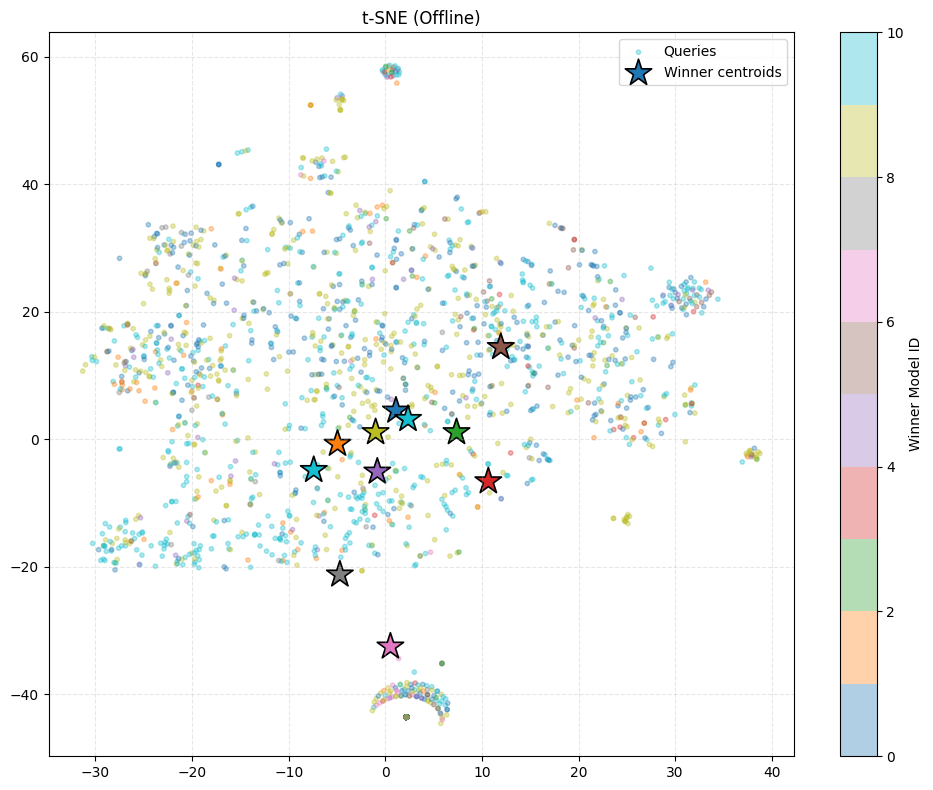

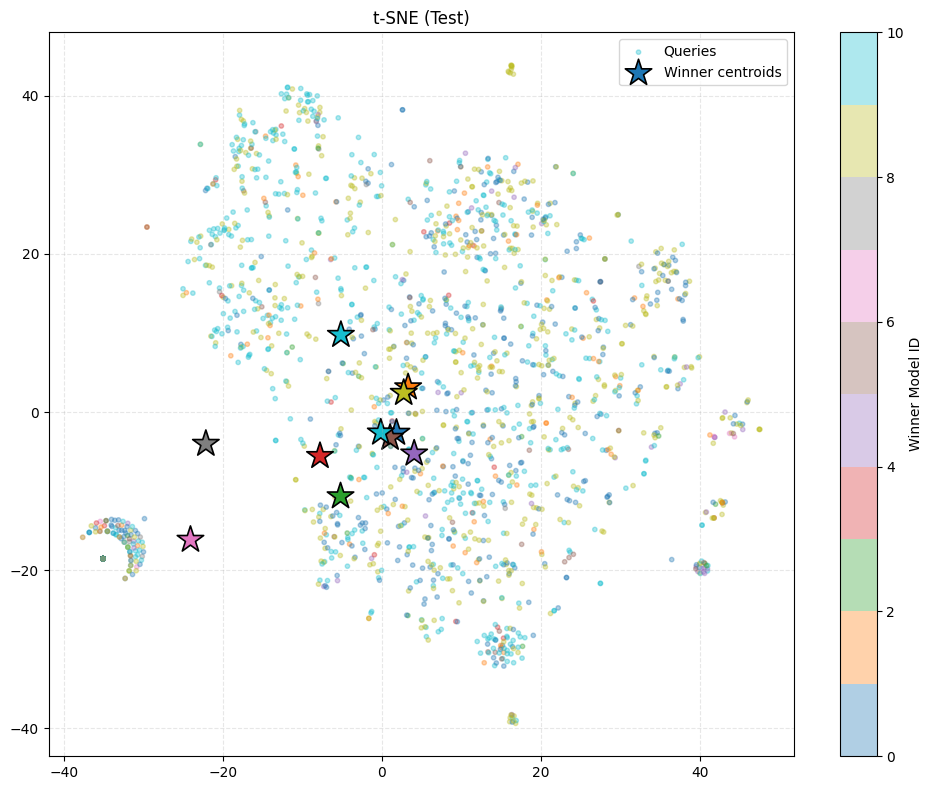

In [1]:
# run_b_diag_routerbench.py
from __future__ import annotations

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

from queue_config import QueueConfig
from mnl_router import MNLRouter

from train import (
    compute_acc_cost_util_all,
    Embedder,
    build_offline_partition_mincover_then_random,
)
from train_by_model.routerbench_train import load_routerbench_pkl as load_routerbench

from b_diagnostics import (
    offline_pretrain_B_supcon_with_val,
    collapse_report,
    plot_tsne,
)

DATA_PATH = "/home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/routerbench_0shot.pkl"


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def plot_tsne_with_centroids(Z: np.ndarray, labels: np.ndarray, title: str, seed: int = 42):
    # PCA init 제거
    tsne = TSNE(n_components=2, perplexity=30, random_state=seed, init="random", learning_rate="auto")
    Z2 = tsne.fit_transform(Z)

    uniq = np.unique(labels)
    centroids = []
    valid = []
    for u in uniq:
        m = (labels == u)
        if m.sum() > 0:
            centroids.append(Z2[m].mean(axis=0))
            valid.append(u)
    centroids = np.asarray(centroids)

    plt.figure(figsize=(10, 8))
    sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=labels, cmap="tab10", s=10, alpha=0.35, label="Queries")
    plt.scatter(centroids[:, 0], centroids[:, 1], c=valid, cmap="tab10",
                marker="*", s=400, edgecolors="black", linewidth=1.2, label="Winner centroids")
    plt.colorbar(sc, label="Winner Model ID")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()



cfg = QueueConfig()

# -----------------------------
# Config
# -----------------------------
cfg.b_type = "mlp"
cfg.d_proj = 128
cfg.b_hidden_mult = 2

cfg.offline_epochs = 300
cfg.supcon_bs = 256
cfg.offline_lr_B = 1e-3
cfg.supcon_temp = 0.1
cfg.supcon_grad_clip = 1.0

# Novelty knobs
cfg.supcon_sem_reg = 0.2
cfg.supcon_soft_targets = True
cfg.supcon_soft_mix = 0.5
cfg.supcon_soft_tau_u = 0.05
cfg.supcon_soft_topm = 64
cfg.supcon_soft_score_mode = "top1"

device = torch.device(cfg.device)
set_seed(int(cfg.seed))

# -----------------------------
# Load data
# -----------------------------
print(f"[Init] Loading {DATA_PATH} ...")
df, models, cost_map = load_routerbench(DATA_PATH, use_cost=bool(cfg.use_cost))
acc_all, util_all = compute_acc_cost_util_all(
    df, models, cost_map, use_cost=bool(cfg.use_cost), lam_cost=float(cfg.lam_cost),
)

texts = df["prompt"].astype(str).tolist()
embedder = Embedder(cfg.embedder_model, device=device)
X_all = embedder.transform(texts)  # (N, d_ctx)
d_ctx = int(X_all.shape[1])
K_models = int(len(models))

idx_all = np.arange(len(df), dtype=np.int64)
idx_tr, idx_te = train_test_split(idx_all, test_size=float(cfg.test_size), random_state=int(cfg.seed), shuffle=True)
X_train, U_train = X_all[idx_tr], util_all[idx_tr]
X_test,  U_test  = X_all[idx_te], util_all[idx_te]

seed_idx, rand_idx, offline_idx, online_idx = build_offline_partition_mincover_then_random(
    util_train=U_train,
    offline_total_ratio=float(getattr(cfg, "offline_total_ratio", 0.2)),
    min_per_model=10,
    tie_eps=1e-9,
    seed=int(cfg.seed),
)
X_off, U_off = X_train[offline_idx], U_train[offline_idx]
print(f"[Partition] Offline={len(X_off)}, Test={len(X_test)}")

# -----------------------------
# Router
# -----------------------------
router = MNLRouter(
    d_ctx=d_ctx,
    n_models=K_models,
    d_proj=int(cfg.d_proj),
    combine_mode=cfg.combine_mode,
    b_type=cfg.b_type,
    b_hidden_mult=int(cfg.b_hidden_mult),
    lr_b=float(cfg.offline_lr_B),
    device=str(cfg.device),
    supcon_temp=float(cfg.supcon_temp),
).to(device)

print(f"[Router] b_type={router.b_type} | d_ctx={router.d_ctx} | d={router.d_final_feature}")
print(f"[Router] x_adapter exists? {router.x_adapter is not None} (frozen={router.x_adapter is not None})")

# -----------------------------
# Offline train (with val split)
# -----------------------------
tb_idx = np.arange(len(X_off), dtype=np.int64)
tb_tr, tb_va = train_test_split(tb_idx, test_size=0.1, random_state=int(cfg.seed), shuffle=True)

offline_pretrain_B_supcon_with_val(
    router=router,
    X_tr=X_off[tb_tr], U_tr=U_off[tb_tr],
    X_va=X_off[tb_va], U_va=U_off[tb_va],
    cfg=cfg,
    n_models=K_models,
    log_every=50,
)

# -----------------------------
# Diagnostics
# -----------------------------
print("\n[Diag] Collapse report...")
rep_tr, Z_tr, y_tr = collapse_report(router, X_off, U_off, n_vis=2000, max_pairs=100_000, seed=0)
rep_te, Z_te, y_te = collapse_report(router, X_test, U_test, n_vis=2000, max_pairs=100_000, seed=1)

print(f"[Train] eff_rank={rep_tr['effective_rank']:.2f} | cos_mean={rep_tr['cos_mean_offdiag']:.3f}")
print(f"[Test ] eff_rank={rep_te['effective_rank']:.2f} | cos_mean={rep_te['cos_mean_offdiag']:.3f}")

if y_tr is not None:
    plot_tsne_with_centroids(Z_tr, y_tr, "t-SNE (Offline)", seed=42)
if y_te is not None:
    plot_tsne_with_centroids(Z_te, y_te, "t-SNE (Test)", seed=43)





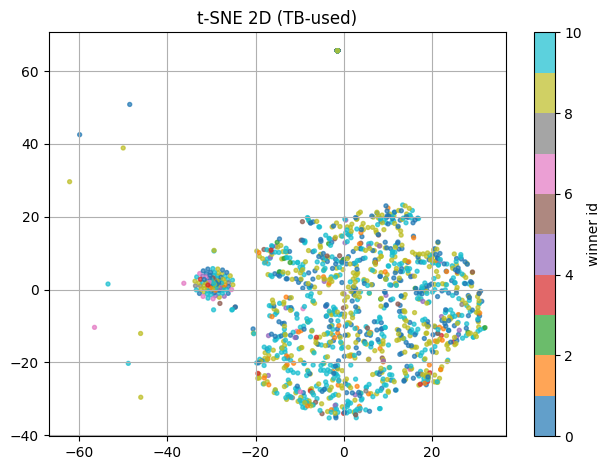

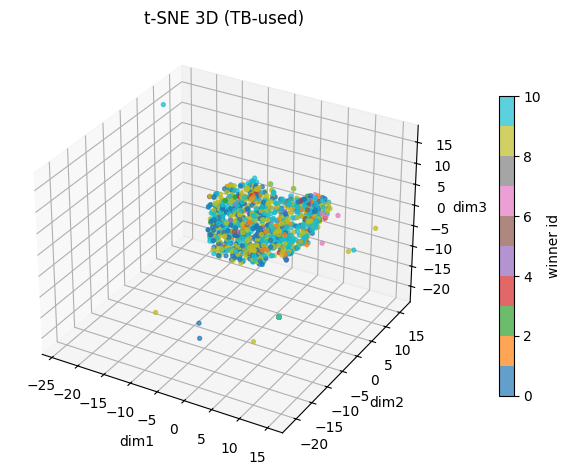

In [2]:
plot_tsne(Z_te, y_te, "t-SNE 2D (TB-used)", tsne_n=1500, perplexity=30)
plot_tsne_3d(Z_te, y_te, "t-SNE 3D (TB-used)", seed=0, tsne_n=1500, perplexity=30)


In [1]:
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import load_dataset  # Hugging Face dataset 로더 추가

# 기존 모듈 임포트 (사용자 환경에 해당 파일들이 있어야 함)
from queue_config import QueueConfig
from mnl_router import MNLRouter

from train import (
    compute_acc_cost_util_all,
    Embedder,
    build_offline_partition_strict_only_per_model,
    build_offline_partition_mincover_then_random,
)
# load_routerbench는 더 이상 파일을 읽는 용도로는 쓰지 않으나, 
# 데이터셋 구조에 따라 내부 로직 참조가 필요할 수 있어 남겨두거나 주석 처리
# from train_by_model.routerbench_train import load_routerbench_pkl as load_routerbench

from b_diagnostics import (
    offline_pretrain_B_supcon_with_val,
    collapse_report, plot_pca, plot_tsne, plot_cos_hist, plot_singular_values,
    probe_separability, plot_pca_3d, plot_tsne_3d,
)

# -------------------------
# Config
# -------------------------
cfg = QueueConfig()
device = torch.device(cfg.device)

import random
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(int(cfg.seed))

btype = str(getattr(cfg, "b_type", "none")).lower().strip()

# -------------------------
# Load data -> acc/util (MODIFIED SECTION)
# -------------------------
print(">>> Loading RZ412/EmbedLLM from Hugging Face...")

# 1. 데이터셋 로드
try:
    ds = load_dataset("RZ412/EmbedLLM")
    # train split을 pandas dataframe으로 변환
    if 'train' in ds:
        df = ds['train'].to_pandas()
    else:
        df = ds[list(ds.keys())[0]].to_pandas() # 첫 번째 split 사용
    print(f"Data Loaded. Shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"데이터셋 로드 실패: {e}. Hugging Face 로그인을 확인하거나 데이터셋 이름을 확인하세요.")

# 2. 모델 목록 및 비용 정의 (중요: 데이터셋에 맞게 수정 필요)
# 기존 pickle 파일에는 models 리스트와 cost_map이 포함되어 있었으나, 
# HF 데이터셋 사용 시 직접 정의하거나 데이터에서 추출해야 합니다.
# 예시: 데이터프레임 컬럼 중 모델 성능과 관련된 컬럼명들을 추출
# 여기서는 사용자가 데이터 구조를 알고 있다고 가정하고 자동 추출 로직을 예시로 넣습니다.
# 만약 데이터셋에 'prompt' 컬럼이 없다면 이름을 변경해줘야 합니다.
if "prompt" not in df.columns and "text" in df.columns:
    df["prompt"] = df["text"]

# [TODO] models와 cost_map을 실제 데이터셋 컬럼에 맞춰 정의해야 합니다.
# 아래는 예시입니다. 실제 데이터셋의 모델 컬럼명으로 교체하세요.
# models = ["gpt-4", "claude-3-opus", "llama-3-70b"] 
# cost_map = {"gpt-4": 10.0, "claude-3-opus": 10.0, "llama-3-70b": 0.5}

# 만약 models 정보를 알 수 없다면, 코드 실행을 위해 임시로 더미 처리가 필요할 수 있습니다.
# 여기서는 기존 로직 유지를 위해 사용자가 직접 models 리스트를 채워넣어야 한다고 가정합니다.
# models = [...] 
# cost_map = {...}

# (임시) 에러 방지를 위한 더미 정의 (실제 사용 시 삭제하고 위 TODO를 해결하세요)
# df, models, cost_map = load_routerbench(...) # 기존 코드 주석 처리

# -------------------------------------------------------------------------
# [주의] 아래 compute_acc_cost_util_all 함수는 df와 models를 인자로 받아
# acc_all, util_all을 계산합니다. df 안에 models에 해당하는 컬럼(점수/정답여부)이 있어야 합니다.
# -------------------------------------------------------------------------
# acc_all, util_all = compute_acc_cost_util_all(
#     df, models, cost_map,
#     use_cost=bool(cfg.use_cost),
#     lam_cost=float(cfg.lam_cost),
# )

# !!! 사용자가 데이터셋 구조에 맞춰 acc_all, util_all을 직접 추출해야 할 수도 있습니다. !!!
# 예: RZ412/EmbedLLM이 이미 embedding만 있는 경우라면 util 정보가 없을 수 있습니다.
# 라우터 학습을 위해서는 '어떤 모델이 이 프롬프트에 대해 성능이 좋은지'에 대한 Ground Truth(Utility)가 필수입니다.
# 아래는 데이터셋에 해당 정보가 있다고 가정하고 진행하는 코드입니다.

# (코드 실행 흐름 유지를 위해 기존 변수명 사용, 실제 데이터 연결 필요)
# prompt 컬럼 확인
texts = df["prompt"].astype(str).tolist()

# -------------------------
# Prompt -> embedding
# -------------------------
embedder = Embedder(cfg.embedder_model, device=device)
X_all = embedder.transform(texts)  # (N, d_ctx)
d_ctx = int(X_all.shape[1])

# [수정 필요] K_models 값을 데이터셋에 맞게 설정
# K_models = int(len(models)) 
K_models = 2 # (임시값) 실제 모델 개수로 수정 필수

# [수정 필요] util_all 생성 (라우팅 레이블)
# 만약 데이터셋에 정답 레이블이 없다면 라우터 학습이 불가능합니다.
# 여기서는 X_all의 크기에 맞춰 임의의 유틸리티를 생성하거나(테스트용), 데이터셋의 컬럼을 매핑해야 합니다.
# 예시: util_all = torch.tensor(df[['model_a_score', 'model_b_score']].values)
if 'util_all' not in locals():
    print("Warning: 'util_all' not defined. Generating dummy utility for dry-run.")
    util_all = np.random.rand(len(df), K_models) # 더미 유틸리티
    acc_all = util_all # 더미 정확도

# -------------------------
# Train/Test split
# -------------------------
idx_all = np.arange(len(df), dtype=np.int64)
idx_tr, idx_te = train_test_split(
    idx_all,
    test_size=float(cfg.test_size),
    random_state=int(cfg.seed),
    shuffle=True,
)

X_train, U_train = X_all[idx_tr], util_all[idx_tr]
X_test,  U_test  = X_all[idx_te], util_all[idx_te]

# -------------------------
# Offline split inside Train (strict-only 정책 적용)
# -------------------------
if btype == "none":
    seed_idx, rand_idx, offline_idx, online_idx = build_offline_partition_strict_only_per_model(
        util_train=U_train,
        n_per_model=int(getattr(cfg, "offline_seed_min_per_model", 10)),
        tie_eps=float(getattr(cfg, "offline_tie_eps", 1e-9)),
        seed=int(cfg.seed) + 999,
    )
else:
    seed_idx, rand_idx, offline_idx, online_idx = build_offline_partition_mincover_then_random(
        util_train=U_train,
        offline_total_ratio=float(getattr(cfg, "offline_total_ratio", 0.2)),
        min_per_model=int(getattr(cfg, "offline_seed_min_per_model", 10)),
        tie_eps=float(getattr(cfg, "offline_tie_eps", 1e-9)),
        seed=int(cfg.seed),
    )

X_off = X_train[offline_idx]
U_off = U_train[offline_idx]

# X_seed, U_seed 정의 추가
X_seed = X_train[seed_idx]
U_seed = U_train[seed_idx]

print(f"[Partition] offline={len(offline_idx)} (seed={len(seed_idx)}, rand={len(rand_idx)}) online={len(online_idx)}")

# tie 통계 확인
mx = U_train.max(axis=1, keepdims=True)
co_first = U_train >= (mx - float(getattr(cfg, "offline_tie_eps", 1e-9)))
tie_size = co_first.sum(axis=1)
print(f"[Tie] strict_ratio(tie==1)={float((tie_size==1).mean()):.4f} tie_mean={float(tie_size.mean()):.3f} tie_max={int(tie_size.max())}")

# -------------------------
# Choose pool for B pretrain diagnostics
# -------------------------
pos_strategy = str(getattr(cfg, "supcon_pos_strategy", "top1")).lower().strip()
if btype == "none":
    # b_type이 none이면 진단을 멈추도록 예외 처리되어 있었으나, 
    # 코드가 계속 돌게 하려면 이 부분을 수정하거나 config에서 b_type을 설정해야 함.
    print("Warning: b_type='none'. Skipping B-pretrain diagnostics setup.")
    # raise RuntimeError("b_type=none이면 B pretrain 진단을 돌릴 게 없다. b_type을 linear/mlp로 바꿔야 한다.")
    X_tb, U_tb = X_off, U_off # Fallback
else:
    X_tb, U_tb = X_off, U_off
    print(f"[B-Pretrain] using OFFLINE full ({pos_strategy})")

# -------------------------
# TB train/val split
# -------------------------
tb_idx = np.arange(len(X_tb), dtype=np.int64)
# 데이터가 너무 적을 경우 에러 방지
if len(tb_idx) > 10:
    tb_tr, tb_va = train_test_split(
        tb_idx,
        test_size=0.1,
        random_state=int(cfg.seed),
        shuffle=True,
    )
    X_tb_tr, U_tb_tr = X_tb[tb_tr], U_tb[tb_tr]
    X_tb_va, U_tb_va = X_tb[tb_va], U_tb[tb_va]
else:
    print("Warning: Not enough data for split. Using full set for both.")
    X_tb_tr, U_tb_tr = X_tb, U_tb
    X_tb_va, U_tb_va = X_tb, U_tb

# -------------------------
# Router init (B only pretrain)
# -------------------------
d_proj_eff = int(cfg.d_proj if btype != "none" else d_ctx)

router = MNLRouter(
    d_ctx=int(d_ctx),
    n_models=int(K_models),
    d_proj=d_proj_eff,
    combine_mode = cfg.combine_mode,
    lambda_0=float(cfg.lambda_0),
    supcon_temp=float(cfg.supcon_temp),
    device=str(cfg.device),
    b_type=str(cfg.b_type),
    b_hidden_mult=int(cfg.b_hidden_mult),
    lr_b=float(cfg.offline_lr_B),
).to(device)

# -------------------------
# Offline B pretrain + diagnostics
# -------------------------
if btype != "none":
    offline_pretrain_B_supcon_with_val(
        router=router,
        X_tr=X_tb_tr, U_tr=U_tb_tr,
        X_va=X_tb_va, U_va=U_tb_va,
        cfg=cfg,
        n_models=K_models,
        log_every=50,
        pos_density_warn=0.25,
    )

# -------------------------
# Collapse / plots / probes
# -------------------------
# 데이터 시각화를 위한 샘플 수 조정 (데이터가 적을 경우 에러 방지)
n_vis_safe = min(3000, len(X_tb))
rep_tb, Z_tb, y_tb = collapse_report(router, X_tb, U_tb, n_vis=n_vis_safe, max_pairs=200_000, seed=0)
print("[Collapse][TB-used]", rep_tb)

n_vis_test_safe = min(3000, len(X_test))
rep_te, Z_te, y_te = collapse_report(router, X_test, U_test, n_vis=n_vis_test_safe, max_pairs=200_000, seed=1)
print("[Collapse][Test]", rep_te)

# Plotting (Display가 없는 서버 환경 등에서는 에러가 날 수 있으니 주의)
try:
    plot_tsne(Z_tb, y_tb, "t-SNE 2D (TB-used)", tsne_n=min(1500, len(Z_tb)), perplexity=30)
    # plot_tsne_3d(Z_tb, y_tb, "t-SNE 3D (TB-used)", seed=0, tsne_n=min(1500, len(Z_tb)), perplexity=30)
except Exception as e:
    print(f"Plotting failed (expected in non-GUI env): {e}")

if y_tb is not None:
    print("[Probe][TB-used]", probe_separability(Z_tb, y_tb, seed=0))
if y_te is not None:
    print("[Probe][Test]", probe_separability(Z_te, y_te, seed=0))

/home/sjy990426/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu128 for torchao version 0.14.0         Please see GitHub issue #2919 for more info


ImportError: cannot import name 'plot_pca' from 'b_diagnostics' (/home/sjy990426/Desktop/LLM_Router/Queing_MNL_Router/B_MNL_Bandit/b_diagnostics.py)